# DX 704 Week 2 Project

This week's project will analyze fresh strawberry price data for a hypothetical "buy low, freeze, and sell high" business.
Strawberries show strong seasonality in their prices compared to other fruits.

![](https://ers.usda.gov/sites/default/files/_laserfiche/Charts/61401/oct14_finding_plattner_fig01.png)

Image source: https://www.ers.usda.gov/amber-waves/2014/october/seasonal-fresh-fruit-price-patterns-differ-across-commodities-the-case-of-strawberries-and-apples

You are considering a business where you buy strawberries when the prices are very low, carefully freeze them, even more carefully defrost them, and then sell them when the prices are high.
You will forecast strawberry price time series and then use them to tactically pick times to buy, freeze, and sell the strawberries.

The full project description, a template notebook, and raw data are available on GitHub at the following link.

https://github.com/bu-cds-dx704/dx704-project-02


### Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Part 1: Backtest Strawberry Prices

Read the provided "strawberry-prices.tsv" with data from 2020 through 2025.
This data is based on data from the U.S. Bureau of Statistics, but transformed so the ground truth is not online.
https://fred.stlouisfed.org/series/APU0000711415

Use the data for 2020 through 2024 to predict monthly prices in 2025.
Spend some time to make sure you are happy with your methodology and prediction accuracy, since you will reuse the methodology to forecast 2026 next.
Save the 2025 backtest predictions as "strawberry-backtest.tsv" with columns month and price.

Hint: beware of missing rows of data.
The source is missing a few months!

Please use the same format for the month column as in the training data, i.e. YYYY-MM-01.
The autograder may not be able to parse other formats.

Submit "strawberry-backtest.tsv" in Gradescope.

In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error, root_mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from prophet import Prophet


In [41]:
df = pd.read_csv('strawberry-prices.tsv', sep='\t')
df

,month,price
0,2020-01-01,4.049
1,2020-02-01,3.625
2,2020-03-01,3.377
3,2020-05-01,3.126
4,2020-06-01,2.926
...,...,...
63,2025-06-01,3.190
64,2025-07-01,3.187
65,2025-08-01,3.430
66,2025-09-01,3.645


In [42]:
df['month'] = pd.to_datetime(df['month'])

# we will impute the training data since some months are missing
train_df = df[df['month'] < '2025-01-01'].set_index('month').asfreq('MS') # monthly start frequency

# dont impute ground truh since it invalidates test set
test_df = df[df['month'] >= '2025-01-01']

In [43]:
# impute price for training
# todo try to use seasonality to improve results
train_df['price'] = train_df['price'].interpolate(method='time')

In [44]:
df = pd.concat([
        train_df.reset_index(), 
        test_df
    ], ignore_index=True).sort_values(by='month').reset_index(drop=True)
df['month_datetime'] = pd.to_datetime(df['month'])

In [45]:
df

,month,price,month_datetime
0,2020-01-01,4.049000,2020-01-01
1,2020-02-01,3.625000,2020-02-01
2,2020-03-01,3.377000,2020-03-01
3,2020-04-01,3.249443,2020-04-01
4,2020-05-01,3.126000,2020-05-01
...,...,...,...
65,2025-06-01,3.190000,2025-06-01
66,2025-07-01,3.187000,2025-07-01
67,2025-08-01,3.430000,2025-08-01
68,2025-09-01,3.645000,2025-09-01


In [46]:
# Rename for Prophet
# prophet_df = df_encoded.rename(mapper={"remainder__month_datetime": "ds", "remainder__price": "y"}, axis=1)
prophet_df = df.rename(mapper={"month_datetime": "ds", "price": "y"}, axis=1)
prophet_df.drop(columns='month', inplace=True)
prophet_df

,y,ds
0,4.049000,2020-01-01
1,3.625000,2020-02-01
2,3.377000,2020-03-01
3,3.249443,2020-04-01
4,3.126000,2020-05-01
...,...,...
65,3.190000,2025-06-01
66,3.187000,2025-07-01
67,3.430000,2025-08-01
68,3.645000,2025-09-01


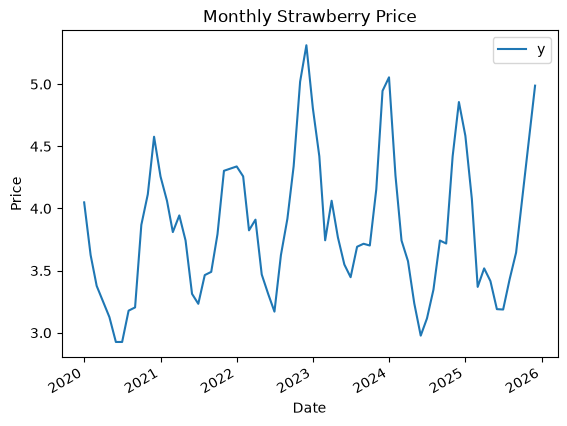

In [47]:
prophet_df.set_index("ds").plot();
plt.title("Monthly Strawberry Price")
plt.xlabel("Date")
plt.ylabel("Price")
None

In [48]:
prophet_df

,y,ds
0,4.049000,2020-01-01
1,3.625000,2020-02-01
2,3.377000,2020-03-01
3,3.249443,2020-04-01
4,3.126000,2020-05-01
...,...,...
65,3.190000,2025-06-01
66,3.187000,2025-07-01
67,3.430000,2025-08-01
68,3.645000,2025-09-01


In [49]:
# 2025 will be the test set
df_train = prophet_df[prophet_df['ds'].dt.year != 2025] #  df['month_datetime'].dt.year
df_test = prophet_df[prophet_df['ds'].dt.year == 2025]

In [50]:
model = Prophet()
model.fit(df_train)

12:52:23 - cmdstanpy - INFO - Chain [1] start processing
12:52:23 - cmdstanpy - INFO - Chain [1] done processing


In [51]:
strawberry_future = model.make_future_dataframe(periods=12, freq='MS') # Get a monthly prediction
strawberry_forecast = model.predict(strawberry_future)
strawberry_forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-01,3.444894,4.053200,4.479772,3.444894,3.444894,0.819149,0.819149,0.819149,0.819149,0.819149,0.819149,0.0,0.0,0.0,4.264043
1,2020-02-01,3.467104,3.485434,3.908835,3.467104,3.467104,0.232932,0.232932,0.232932,0.232932,0.232932,0.232932,0.0,0.0,0.0,3.700036
2,2020-03-01,3.487880,3.244334,3.674229,3.487880,3.487880,-0.032527,-0.032527,-0.032527,-0.032527,-0.032527,-0.032527,0.0,0.0,0.0,3.455353
3,2020-04-01,3.510090,3.135432,3.582845,3.510090,3.510090,-0.157353,-0.157353,-0.157353,-0.157353,-0.157353,-0.157353,0.0,0.0,0.0,3.352738
4,2020-05-01,3.531584,2.949844,3.346124,3.531584,3.531584,-0.394961,-0.394961,-0.394961,-0.394961,-0.394961,-0.394961,0.0,0.0,0.0,3.136623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,2025-08-01,3.651454,3.034355,3.459079,3.629908,3.671361,-0.411602,-0.411602,-0.411602,-0.411602,-0.411602,-0.411602,0.0,0.0,0.0,3.239852
68,2025-09-01,3.635711,3.159161,3.578877,3.610210,3.660191,-0.259369,-0.259369,-0.259369,-0.259369,-0.259369,-0.259369,0.0,0.0,0.0,3.376342
69,2025-10-01,3.620476,3.411589,3.843953,3.589376,3.648513,0.018539,0.018539,0.018539,0.018539,0.018539,0.018539,0.0,0.0,0.0,3.639014
70,2025-11-01,3.604732,3.900584,4.337329,3.568793,3.636607,0.525860,0.525860,0.525860,0.525860,0.525860,0.525860,0.0,0.0,0.0,4.130592


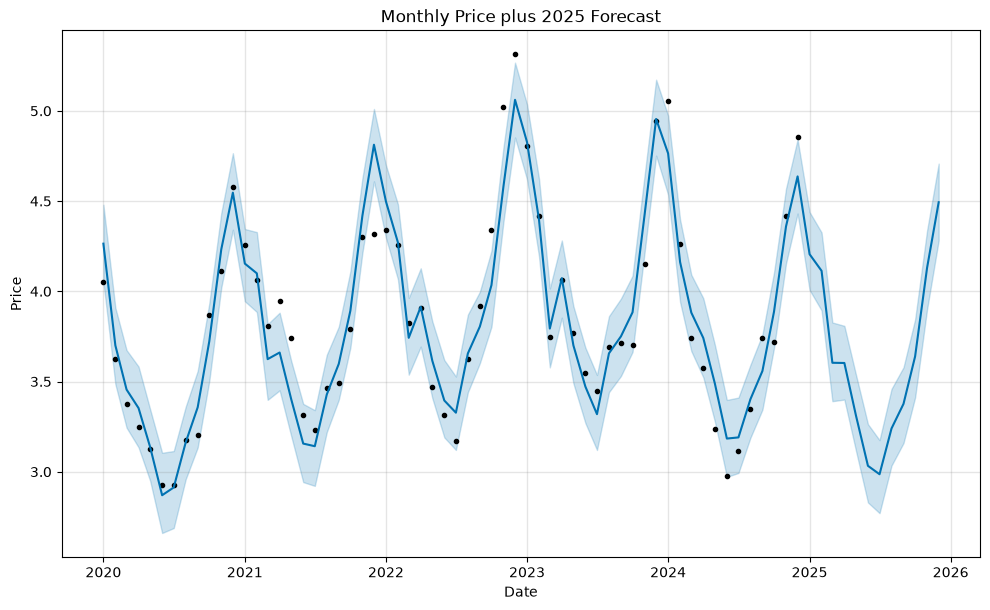

In [52]:
model.plot(strawberry_forecast)

plt.title("Monthly Price plus 2025 Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
None

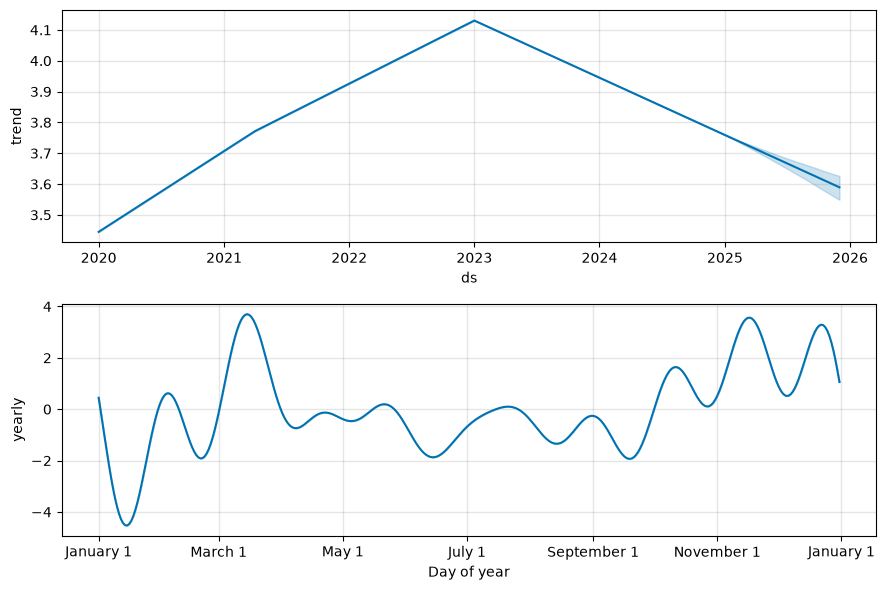

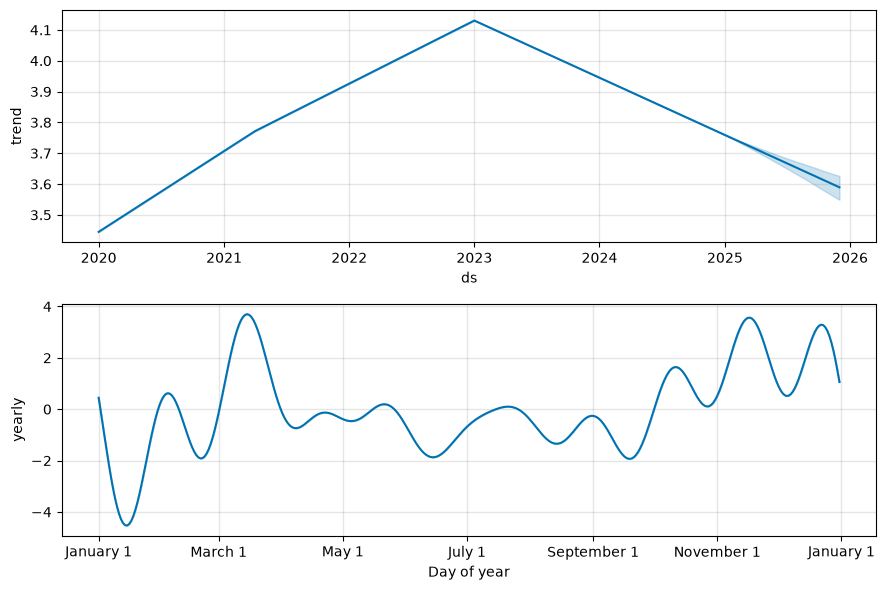

In [53]:
model.plot_components(strawberry_forecast)

In [54]:
backtest_preds = strawberry_forecast[strawberry_forecast['ds'].dt.year == 2025]

In [55]:
df_test['month'] = df_test['ds'].dt.month
df_test

,y,ds,month
60,4.584,2025-01-01,1
61,4.077,2025-02-01,2
62,3.369,2025-03-01,3
63,3.518,2025-04-01,4
64,3.416,2025-05-01,5
65,3.190,2025-06-01,6
66,3.187,2025-07-01,7
67,3.430,2025-08-01,8
68,3.645,2025-09-01,9
69,4.988,2025-12-01,12


In [56]:
y_pred = pd.DataFrame({
    'yhat': backtest_preds['yhat'],
    'month': backtest_preds['ds'].dt.month,
    'ds': backtest_preds['ds']
})
y_pred

,yhat,month,ds
60,4.205535,1,2025-01-01
61,4.113587,2,2025-02-01
62,3.603901,3,2025-03-01
63,3.602779,4,2025-04-01
64,3.311443,5,2025-05-01
65,3.032822,6,2025-06-01
66,2.986203,7,2025-07-01
67,3.239852,8,2025-08-01
68,3.376342,9,2025-09-01
69,3.639014,10,2025-10-01


In [57]:
backtest_merged = pd.merge(df_test, y_pred, on='month', how='right')
backtest_merged

,y,ds_x,month,yhat,ds_y
0,4.584,2025-01-01,1,4.205535,2025-01-01
1,4.077,2025-02-01,2,4.113587,2025-02-01
2,3.369,2025-03-01,3,3.603901,2025-03-01
3,3.518,2025-04-01,4,3.602779,2025-04-01
4,3.416,2025-05-01,5,3.311443,2025-05-01
5,3.190,2025-06-01,6,3.032822,2025-06-01
6,3.187,2025-07-01,7,2.986203,2025-07-01
7,3.430,2025-08-01,8,3.239852,2025-08-01
8,3.645,2025-09-01,9,3.376342,2025-09-01
9,NaN,NaT,10,3.639014,2025-10-01


In [58]:
backtest_merged_without_na = backtest_merged.dropna()
backtest_merged_without_na

,y,ds_x,month,yhat,ds_y
0,4.584,2025-01-01,1,4.205535,2025-01-01
1,4.077,2025-02-01,2,4.113587,2025-02-01
2,3.369,2025-03-01,3,3.603901,2025-03-01
3,3.518,2025-04-01,4,3.602779,2025-04-01
4,3.416,2025-05-01,5,3.311443,2025-05-01
5,3.190,2025-06-01,6,3.032822,2025-06-01
6,3.187,2025-07-01,7,2.986203,2025-07-01
7,3.430,2025-08-01,8,3.239852,2025-08-01
8,3.645,2025-09-01,9,3.376342,2025-09-01
11,4.988,2025-12-01,12,4.493571,2025-12-01


In [59]:
mean_squared_error(y_true=backtest_merged_without_na['y'], y_pred=backtest_merged_without_na['yhat'])

0.0635690109118136

In [60]:
root_mean_squared_error(y_true=backtest_merged_without_na['y'], y_pred=backtest_merged_without_na['yhat'])

0.25212895690858994

In [61]:
backtest_df = pd.DataFrame({
    'month': backtest_merged['ds_y'],
    'price': backtest_merged['yhat']
}).reset_index(drop=True)
backtest_df

,month,price
0,2025-01-01,4.205535
1,2025-02-01,4.113587
2,2025-03-01,3.603901
3,2025-04-01,3.602779
4,2025-05-01,3.311443
5,2025-06-01,3.032822
6,2025-07-01,2.986203
7,2025-08-01,3.239852
8,2025-09-01,3.376342
9,2025-10-01,3.639014


In [62]:
backtest_df.to_csv('strawberry-backtest.tsv', sep='\t', index=False)

## Part 2: Backtest Errors

What are the mean and standard deviation of the residuals between your backtest predictions and the ground truth?

Write the mean and standard deviation to a file "backtest-accuracy.tsv" with two columns, mean and std.

In [63]:
residuals = test_df['price'].values - backtest_merged_without_na['yhat'].values
residuals

array([ 0.37846451, -0.03658707, -0.23490139, -0.08477924,  0.10455685,
        0.15717797,  0.20079675,  0.19014788,  0.26865813,  0.4944291 ])

In [64]:
residuals_std = np.std(residuals)
residuals_mean = np.mean(residuals)

In [65]:
backtest_accuracy = pd.DataFrame({
    'mean': [residuals_mean],
    'std': [residuals_std]
})

backtest_accuracy.to_csv('backtest-accuracy.tsv', sep='\t', index=False)
backtest_accuracy

,mean,std
0,0.143796,0.207103


Hint: If the mean residual in your backtest is not close to zero, then your model is likely missing a systematic change and you should go back to improve it.

Submit "backtest-accuracy.tsv" in Gradescope.

## Part 3: Forecast Strawberry Prices

Use all the data from 2020 through 2025 to predict monthly prices in 2026 using the same methodology from part 1.
Make a monthly forecast for each month of 2026 and save it as "strawberry-forecast.tsv" with columns for month and price.


In [66]:
model = Prophet()
model.fit(prophet_df)

strawberry_future = model.make_future_dataframe(periods=12, freq='MS') # Get a monthly prediction
strawberry_forecast = model.predict(strawberry_future)

12:52:23 - cmdstanpy - INFO - Chain [1] start processing
12:52:24 - cmdstanpy - INFO - Chain [1] done processing


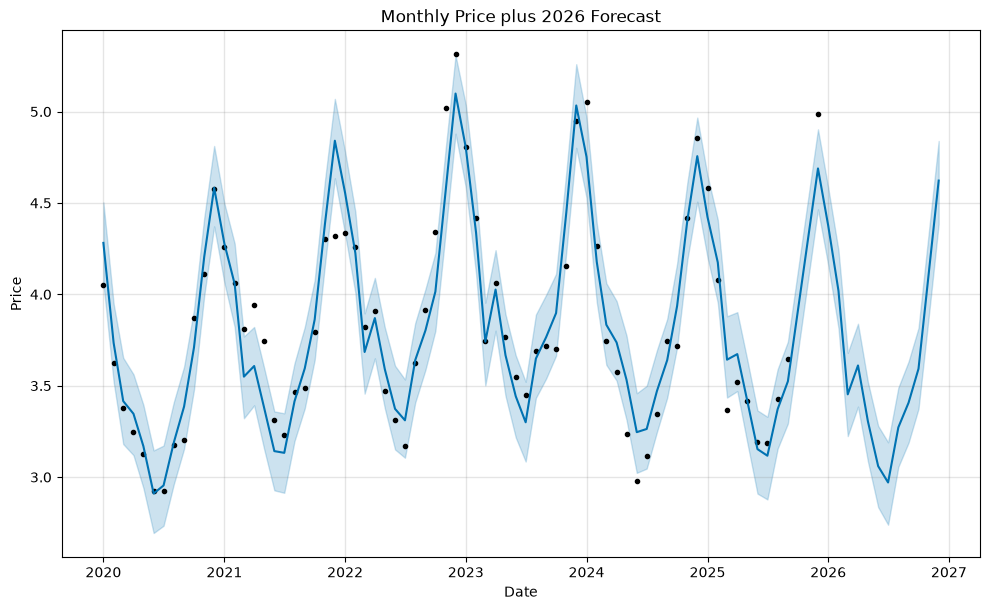

In [67]:
model.plot(strawberry_forecast)

plt.title("Monthly Price plus 2026 Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
None

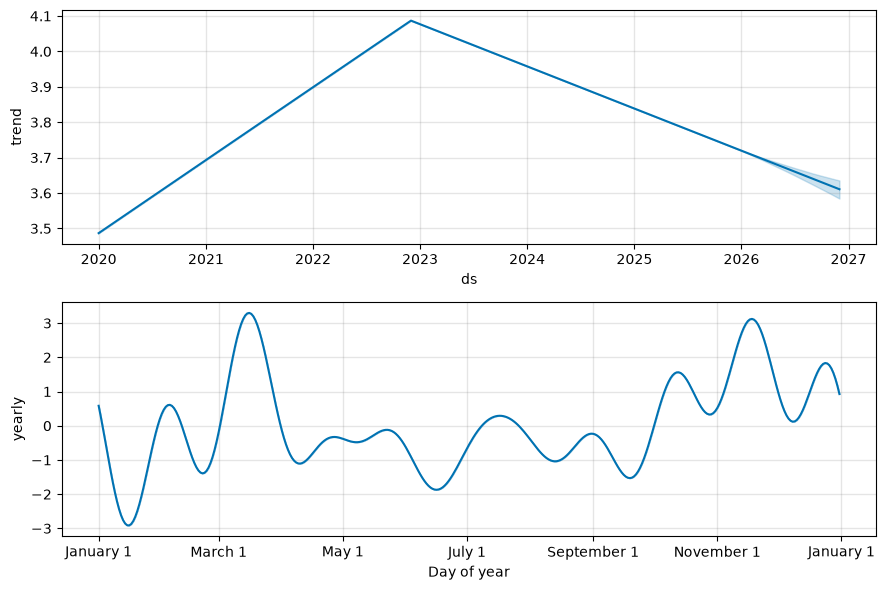

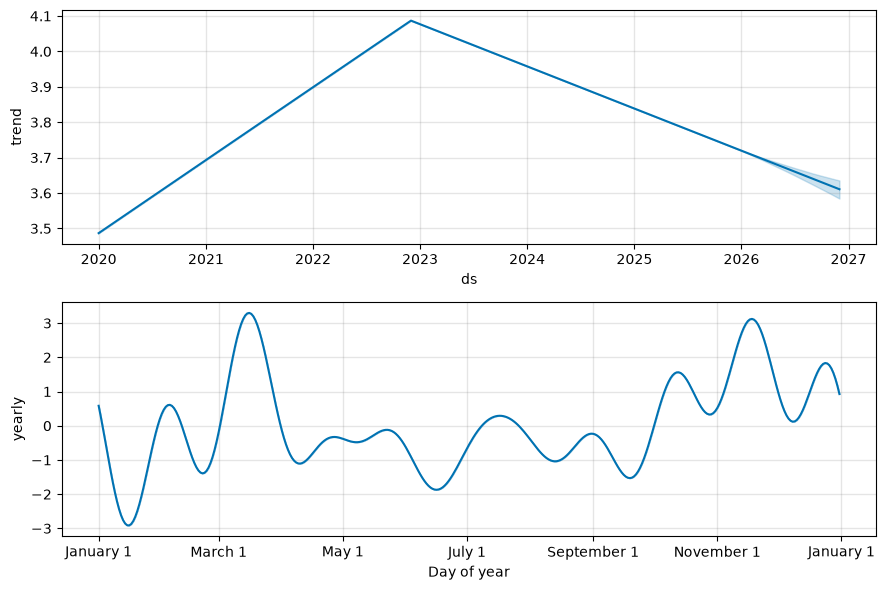

In [68]:
model.plot_components(strawberry_forecast)

In [69]:
forecast_preds = strawberry_forecast[strawberry_forecast['ds'].dt.year == 2026]
forecast_preds

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
70,2026-01-01,3.719601,4.160665,4.582838,3.719226,3.719893,0.655610,0.655610,0.655610,0.655610,0.655610,0.655610,0.0,0.0,0.0,4.375210
71,2026-02-01,3.709497,3.815574,4.240926,3.708221,3.710794,0.309530,0.309530,0.309530,0.309530,0.309530,0.309530,0.0,0.0,0.0,4.019027
72,2026-03-01,3.700371,3.224358,3.679879,3.697740,3.703004,-0.247587,-0.247587,-0.247587,-0.247587,-0.247587,-0.247587,0.0,0.0,0.0,3.452784
73,2026-04-01,3.690268,3.385589,3.839223,3.685903,3.694705,-0.079442,-0.079442,-0.079442,-0.079442,-0.079442,-0.079442,0.0,0.0,0.0,3.610826
74,2026-05-01,3.680490,3.085886,3.519506,3.673975,3.686707,-0.375642,-0.375642,-0.375642,-0.375642,-0.375642,-0.375642,0.0,0.0,0.0,3.304848
75,2026-06-01,3.670386,2.835653,3.280312,3.661871,3.678565,-0.610513,-0.610513,-0.610513,-0.610513,-0.610513,-0.610513,0.0,0.0,0.0,3.059873
76,2026-07-01,3.660609,2.739335,3.190419,3.649770,3.670761,-0.690128,-0.690128,-0.690128,-0.690128,-0.690128,-0.690128,0.0,0.0,0.0,2.970481
77,2026-08-01,3.650505,3.055726,3.489367,3.636769,3.663171,-0.378498,-0.378498,-0.378498,-0.378498,-0.378498,-0.378498,0.0,0.0,0.0,3.272007
78,2026-09-01,3.640402,3.188964,3.632766,3.623818,3.655330,-0.233003,-0.233003,-0.233003,-0.233003,-0.233003,-0.233003,0.0,0.0,0.0,3.407399
79,2026-10-01,3.630624,3.374157,3.816093,3.610997,3.648604,-0.037653,-0.037653,-0.037653,-0.037653,-0.037653,-0.037653,0.0,0.0,0.0,3.592971


In [70]:
forecast_df = forecast_preds[['ds', 'yhat']]
forecast_df.rename(columns={
    'ds': 'month',
    'yhat': 'price'
}, inplace=True)
forecast_df

,month,price
70,2026-01-01,4.375210
71,2026-02-01,4.019027
72,2026-03-01,3.452784
73,2026-04-01,3.610826
74,2026-05-01,3.304848
75,2026-06-01,3.059873
76,2026-07-01,2.970481
77,2026-08-01,3.272007
78,2026-09-01,3.407399
79,2026-10-01,3.592971


In [71]:
forecast_df.to_csv('strawberry-forecast.tsv', sep='\t', index=False)

Submit "strawberry-forecast.tsv" in Gradescope.

## Part 4: Buy Low, Freeze and Sell High

Using your 2026 forecast, analyze the profit picking different pairs of months to buy and sell strawberries.
Maximize your profit assuming that it costs &dollar;0.20 per pint to freeze the strawberries, &dollar;0.10 per pint per month to store the frozen strawberries and there is a 10% price discount from selling previously frozen strawberries.
So, if you buy a pint of strawberies for &dollar;1, freeze them, and sell them for &dollar;2 three months after buying them, then the profit is &dollar;2 * 0.9 - &dollar;1 - &dollar;0.20 - &dollar;0.10 * 3 = &dollar;0.30 per pint.
To evaluate a given pair of months, assume that you can invest &dollar;1,000,000 to cover all costs, and that you buy as many pints of strawberries as possible.

Write the results of your analysis to a file "timings.tsv" with columns for the buy_month, sell_month, pints_purchased, and expected_profit.

In [80]:
"""
How do we find the optimal buy and sell time?

The brute force approach is to try every combination.
Try each month 0..12
    For each month try all possible sell months after that month. Check the profit and save the results for later
Return optimal solution
"""
budget = 1_000_000

result_pints_purchased = []
result_buy_month = []
result_sell_month = []
result_expected_profit = []

for i in range(len(forecast_df)):
  buy_row = forecast_df.iloc[i]
  buy_month = buy_row.month
  buy_price = buy_row.price

  for j in range(i+1, len(forecast_df)):
    sell_row = forecast_df.iloc[j]
    sell_month = sell_row.month
    sell_price = sell_row.price

    # Equal to sell month - buy month
    num_months_frozen = sell_month.month - buy_month.month

    # Static 10% off for selling previously frozen strawberries
    frozen_price_discount = 0.9

    # $0.20 per pint to freeze the strawberries
    freeze_cost_per_pint = 0.2

    # $0.10 off per pint per month the strawberries were frozen
    storage_cost_per_pint = 0.1 * num_months_frozen

    expected_profit_per_pint = (sell_price * frozen_price_discount) - buy_price - freeze_cost_per_pint - storage_cost_per_pint
    # print(f"Buying for {buy_price} and selling for {sell_price}")
    # print(f"{expected_profit_per_pint=}")

    # We have $1_000_000 to cover all costs. Calculate buy price, freeze cost, and storage cost and do a divison by budget
    pints_purchased = budget // (buy_price + freeze_cost_per_pint + storage_cost_per_pint)

    expected_profit = expected_profit_per_pint * pints_purchased

    result_expected_profit.append(expected_profit)
    result_pints_purchased.append(pints_purchased)
    result_buy_month.append(buy_row.month)
    result_sell_month.append(sell_row.month)

best_profit_idx = np.argmax(result_expected_profit)

result_expected_profit[best_profit_idx], result_buy_month[best_profit_idx], result_sell_month[best_profit_idx], result_pints_purchased[best_profit_idx]

(np.float64(133434.74660409303),
 Timestamp('2026-07-01 00:00:00'),
 Timestamp('2026-12-01 00:00:00'),
 np.float64(272443.0))

In [81]:
timings = pd.DataFrame({
    'buy_month': result_buy_month,
    'sell_month': result_sell_month,
    'pints_purchased': result_pints_purchased,
    'expected_profit': result_expected_profit
})
timings

,buy_month,sell_month,pints_purchased,expected_profit
0,2026-01-01,2026-02-01,213894.0,-226318.203836
1,2026-01-01,2026-03-01,209414.0,-349240.680360
2,2026-01-01,2026-04-01,205119.0,-333414.222054
3,2026-01-01,2026-05-01,200996.0,-402162.304134
4,2026-01-01,2026-06-01,197036.0,-457384.471380
...,...,...,...,...
61,2026-09-01,2026-11-01,262646.0,-27131.721122
62,2026-09-01,2026-12-01,255924.0,64711.184676
63,2026-10-01,2026-11-01,256873.0,-48516.410637
64,2026-10-01,2026-12-01,250440.0,41893.971621


In [82]:
timings.to_csv('timings.tsv', sep='\t', index=False)

Submit "timings.tsv" in Gradescope.

## Part 5: Strategy Check

What is the best profit scenario according to your previous timing analysis?
How much does that profit change if the sell price is off by one standard deviation from your backtest analysis?
(Variation in the sell price is more dangerous because you can see the buy price before fully committing.)

Write the results to a file "check.tsv" with columns `best_profit` and `one_std_profit`.
To be clear, `one_std_profit` should be the number of pints bought in your best profit scenario times your backtested standard deviation of the residual.
This represents the standard deviation in revenue when selling if you explicitly assume that you buy according to the best profit scenario and your backtest standard deviation is representative of the future prices.

In [83]:
best_profit = result_expected_profit[best_profit_idx]
pints_purchased =result_pints_purchased[best_profit_idx]

one_std_profit = pints_purchased * residuals_std

check = pd.DataFrame({
    'best_profit': [best_profit],
    'one_std_profit': [one_std_profit]
})
check

,best_profit,one_std_profit
0,133434.746604,56423.741607


In [84]:
check.to_csv('check.tsv', sep='\t', index=False)

Submit "check.tsv" in Gradescope.

## Part 6: Acknowledgments

Make a file "acknowledgments.txt" documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgments are appropriate, just write none in the file.


Submit "acknowledgments.txt" in Gradescope.

## Part 7: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.
You do not need to provide code for data collection if you did that by manually.

Submit "project.ipynb" in Gradescope.